# Using the $\sigma(M)$ emulator

This notebook provides a tutorial on how to use the emulated $\sigma(M)$ as a backend to speed up calculations.
For a list of available emulators, see {doc}`../api/halox.emus`.

## How to call the emulator and a comparison between the emulated and analytical fucntion

In [1]:
from halox import cosmology, hmf, bias, emus, lss
import jax.numpy as jnp
import matplotlib.pyplot as plt
from matplotlib_inline.backend_inline import set_matplotlib_formats

plt.style.use(["seaborn-v0_8-darkgrid", "petroff10"])
plt.rcParams.update({"xtick.direction": "in", "ytick.direction": "in"})
set_matplotlib_formats('svg')


/Users/fkeruzore/Software/halox/.venv/lib/python3.12/site-packages/jax_cosmo/__init__.py:2: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound


## Building the cosmology and mass range

In [2]:
# Create a Planck 2018 cosmology
cosmo = cosmology.Planck18()
print(f"Hubble parameter h = {cosmo.h}")
print(f"Matter density Ω_m = {cosmo.Omega_m}")
print(f"Baryon density Ω_b = {cosmo.Omega_b}")
print(f"Cold dark matter density Ω_c = {cosmo.Omega_c}")
print(f"Power spectrum normalization σ_8 = {cosmo.sigma8}")

# Mass range from 10^10 to 10^16 h^-1 M_sun
M = jnp.logspace(11, 16, 100)
z = 0.0
delta_c = 200.0

Hubble parameter h = 0.6766
Matter density Ω_m = 0.30964
Baryon density Ω_b = 0.04897
Cold dark matter density Ω_c = 0.26067
Power spectrum normalization σ_8 = 0.8102


## Calling the emualted versus non-emulated functions

To use the emulated value of $\sigma(M)$, instantiate an emulator and pass it into the sigma_M function. 

The emulator object here is using the default network weights and training ranges.
If you have another weight file from an emulator you have trained you can pass this into the emulator instantiation as the kwarg weight_file
(see {doc}`../api/halox.emus` for a list of pre-packaged weight files):

In [3]:
emu = emus.sigmaM.SigmaMEmulator()
sigma_fid = lss.sigma_M(M, z, cosmo)
sigma_emu = lss.sigma_M(M, z, cosmo, emu=emu)

The same syntax works for other functions that require computing $\sigma(M)$, i.e.

In [4]:
hmf_fid = hmf.tinker08_mass_function(M, z, cosmo)  # analytic
hmf_fid = hmf.tinker08_mass_function(M, z, cosmo, emu=emu)  # emulated

bias_fid = bias.tinker10_bias(M, z, cosmo)  # analytic
bias_fid = bias.tinker10_bias(M, z, cosmo, emu=emu)  # emulated

## Comparison

Below is a comparison of $\sigma(M)$ calculations, followed by a comparison of HMF and Halo Bias using emulated values of $\sigma(M)$.

### $\sigma(M)$

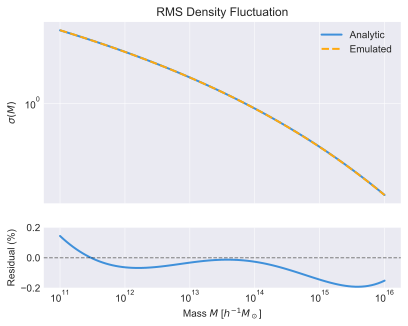

In [5]:
# fractional residuals
residuals = (sigma_emu - sigma_fid) / sigma_fid * 100

fig, axs = plt.subplots(
    2, 1, sharex=True, gridspec_kw={"height_ratios": [3, 1]}
)

# --- Top: sigma(M) ---
axs[0].plot(M, sigma_fid, label="Analytic", lw=2)
axs[0].plot(M, sigma_emu, "--", label="Emulated", lw=2)

axs[0].set_xscale("log")
axs[0].set_yscale("log")
axs[0].set_ylabel(r"$\sigma(M)$")
axs[0].set_title(r"RMS Density Fluctuation")
axs[0].legend()

# --- Bottom: residuals ---
axs[1].plot(M, residuals, lw=2)

axs[1].axhline(0.0, color="k", linestyle="--", alpha=0.5)

axs[1].set_xscale("log")
axs[1].set_ylabel("Residual (%)")
axs[1].set_xlabel(r"Mass $M$ [$h^{-1} M_\odot$]")
axs[1].set_ylim(-0.2, 0.2)

for ax in axs:
    ax.grid(True, alpha=1.0)
fig.align_ylabels(axs)

### Halo mass function

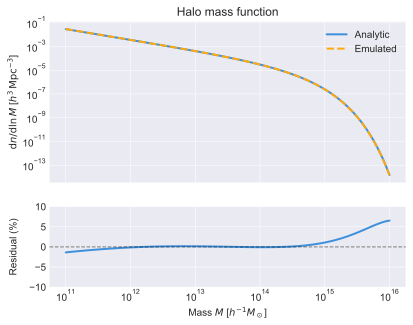

In [6]:
dn_dlnM = hmf.tinker08_mass_function(M, z, cosmo, delta_c)
dn_dlnM_emu = hmf.tinker08_mass_function(M, z, cosmo, delta_c, emu=emu)

fig, axs = plt.subplots(
    2, 1, sharex=True, gridspec_kw={"height_ratios": [2, 1]}
)

axs[0].set_title("Halo mass function")
axs[0].set_ylabel(r"${\rm d}n/{\rm d}\ln M$ [$h^3 \, {\rm Mpc}^{-3}$]")
axs[0].set_xscale("log")
axs[0].set_yscale("log")
axs[0].plot(M, dn_dlnM, ls="-", lw=2, label="Analytic")
axs[0].plot(M, dn_dlnM_emu, ls="--", lw=2, label="Emulated")
axs[0].legend()

axs[1].plot(M, ((dn_dlnM / dn_dlnM_emu) - 1) * 100, lw=2)
axs[1].axhline(0.0, color="k", linestyle="--", alpha=0.5)
axs[1].set_ylim(-10, 10)
axs[1].set_xlabel(r"Mass $M$ [$h^{-1} M_\odot$]")
axs[1].set_ylabel("Residual (%)")
axs[1].set_xscale("log")

for ax in axs:
    ax.grid(True, alpha=1.0)
fig.align_ylabels(axs)

### Halo bias

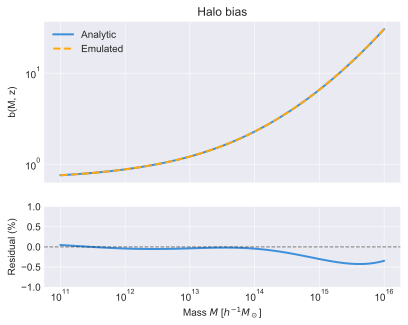

In [7]:
hbias = bias.tinker10_bias(M, z, cosmo, delta_c)
hbias_emu = bias.tinker10_bias(M, z, cosmo, delta_c, emu=emu)

fig, axs = plt.subplots(
    2, 1, sharex=True, gridspec_kw={"height_ratios": [2, 1]}
)

axs[0].set_title("Halo bias")
axs[0].set_ylabel(r"b(M, z)")
axs[0].set_xscale("log")
axs[0].set_yscale("log")
axs[0].plot(M, hbias, ls="-", lw=2, label="Analytic")
axs[0].plot(M, hbias_emu, ls="--", lw=2, label="Emulated")
axs[0].legend()

axs[1].plot(M, ((hbias / hbias_emu) - 1) * 100, lw=2)
axs[1].axhline(0.0, color="k", linestyle="--", alpha=0.5)
axs[1].set_ylim(-1, 1)
axs[1].set_xlabel(r"Mass $M$ [$h^{-1} M_\odot$]")
axs[1].set_ylabel("Residual (%)")
axs[1].set_xscale("log")

for ax in axs:
    ax.grid(True, alpha=1.0)
fig.align_ylabels(axs)